<a href="https://colab.research.google.com/github/Yuliana-Lestari/data-science-2026/blob/main/Pertemuan11_YulianaLestari_250401020199.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan
np.random.seed(42)

grp1 = np.random.normal([30,20],[6,8],(100,2))
grp2 = np.random.normal([70,55],[8,10],(100,2))
grp3 = np.random.normal([110,85],[10,8],(100,2))

data = np.vstack([grp1,grp2,grp3])

df = pd.DataFrame(data,
                  columns=['pendapatan_tahunan',
                           'skor_belanja'])

df['usia']=np.random.randint(18,65,len(df))
df['gender']=np.random.choice(['L','P'],len(df))

print(df.shape)

df.describe()

(300, 4)


,pendapatan_tahunan,skor_belanja,usia
count,300.000000,300.000000,300.000000
mean,69.960743,53.232291,42.066667
std,33.819247,27.407753,13.594051
min,14.281529,4.099449,18.000000
25%,32.141708,25.597110,30.000000
50%,70.844774,55.114127,43.000000
75%,103.400732,78.163808,53.000000
max,140.788808,103.165543,64.000000


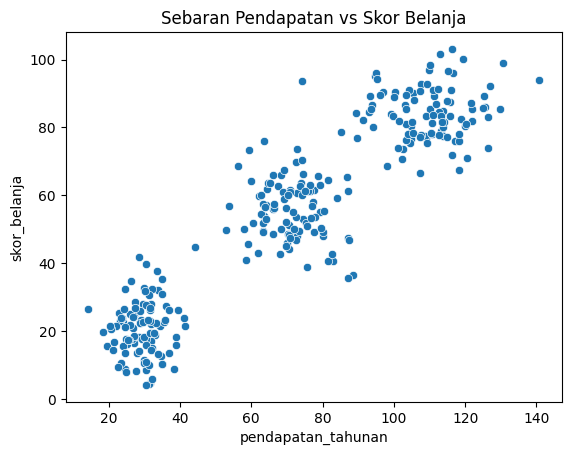

In [2]:
sns.scatterplot(
    data=df,
    x='pendapatan_tahunan',
    y='skor_belanja'
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan',
        'skor_belanja']].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.mean(axis=0))
print(X_scaled.std(axis=0))

[-2.88657986e-17  7.92699240e-16]
[1. 1.]


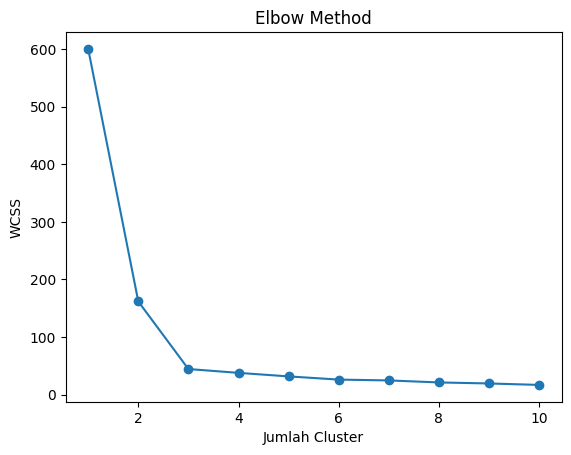

In [4]:
from sklearn.cluster import KMeans

wcss=[]

for k in range(1,11):
    km=KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [5]:
from sklearn.metrics import silhouette_score

model=KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++"
)

model.fit(X_scaled)

df["cluster"]=model.labels_

print("WCSS :",model.inertia_)
print("Silhouette :",silhouette_score(X_scaled,
                                     model.labels_))

print(df.groupby("cluster")[[
    "pendapatan_tahunan",
    "skor_belanja"
]].mean())

WCSS : 44.5564179805733
Silhouette : 0.6953274658286891
         pendapatan_tahunan  skor_belanja
cluster                                  
0                 70.994733     55.050104
1                 29.306614     20.272179
2                109.198842     84.084249


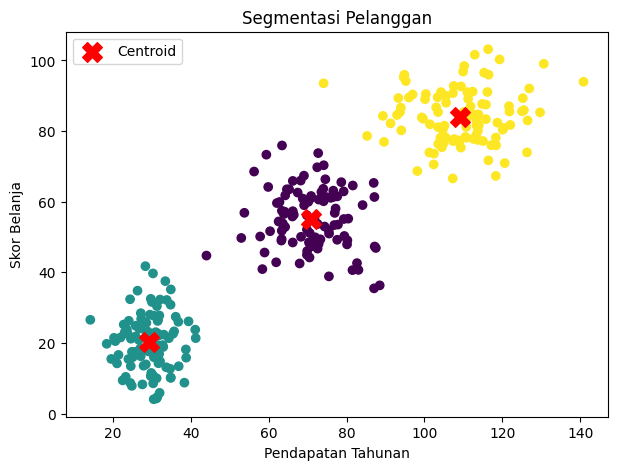

In [6]:
centroids=scaler.inverse_transform(
    model.cluster_centers_
)

plt.figure(figsize=(7,5))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis"
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=200,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan")

plt.legend()
plt.show()

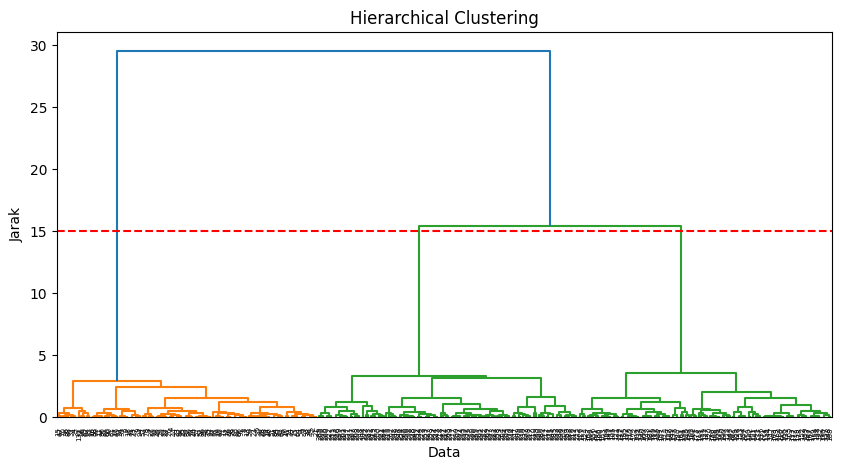

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.title("Hierarchical Clustering")
plt.xlabel("Data")
plt.ylabel("Jarak")

plt.axhline(y=15,color="red",linestyle="--")

plt.show()

Hasil Elbow Method menunjukkan titik siku berada pada K=3 sehingga jumlah cluster optimal adalah 3.

Cluster 0 = Pendapatan rendah dan skor belanja rendah (Hemat)

Cluster 1 = Pendapatan sedang dan skor belanja sedang (Menengah)

Cluster 2 = Pendapatan tinggi dan skor belanja tinggi (Premium)